## Setup

In [1]:
import pandas as pd
import numpy as np
import os
import sys
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
GTE_DIR=os.environ["GTE_DIR"]
from functools import  partial
from glaciation_time_estimator.data_postprocessing.Job_result_fp_generator import generate_tracking_filenames
from glaciation_time_estimator.auxiliary_func.config_reader import read_config
import cmcrameri
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl

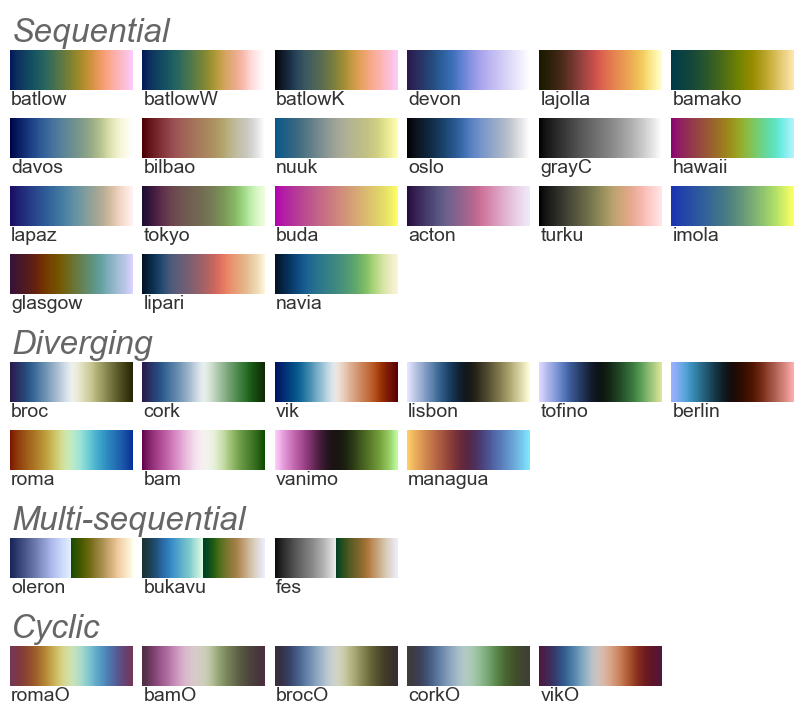

In [2]:
%matplotlib inline
plt.rc('font',family='arial')
plt.rcParams.update({"font.size":6})
font= fm.FontProperties(family='arial')
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
cmcrameri.cm.show_cmaps()

In [3]:
config = read_config(
    os.path.join(GTE_DIR,'configs/2007_tracking/01_01.yaml'))
analyze_year=True
year=2022
global global_rmse
global_rmse = config["Global_sqrt_mse"]
ice_cont_crit_frac = 0.05
# classifiacation_palette = ['#e41a1c', '#377eb8', "#4daf4a"]
classifiacation_palette = ['#e41a1c', '#377eb8', "#4daf4a"]

## Load data

In [4]:
if os.uname()[1]=="n2o":
    combined_cloud_df = pd.read_parquet("/net/n2o/wolke_scratch/dnikolo/Final_results/2009_all.parquet")
if os.uname()[1][:3]=="eu-":
    combined_cloud_df = pd.read_parquet(f"/cluster/work/climate/dnikolo/Cloud_analysis/Final_results/{year}_all.parquet")
combined_cloud_df=combined_cloud_df[~combined_cloud_df.is_large_pix_cloud]
combined_cloud_df = combined_cloud_df[(combined_cloud_df.avg_lat >30) | (combined_cloud_df.avg_lat<-30)]


: 

## Publication figures

In [ ]:
# mpl.use('cairo')

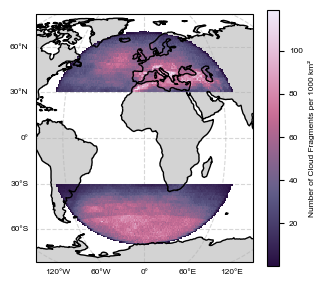

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ---- Example DataFrame 'sample' ----
# sample = pd.DataFrame({'avg_lon': [...], 'avg_lat': [...]})
sample=combined_cloud_df
# 1. Define bin edges for 1° increments
lon_bins = np.arange(-80, 82, 1)
lat_bins = np.arange(-80, 82, 1)

# 2. Compute the 2D histogram
heatmap, lon_edges, lat_edges = np.histogram2d(
    sample['avg_lon'],
    sample['avg_lat'],
    bins=[lon_bins, lat_bins]
)

# 3. Mask zero-count cells so they're transparent
area_factors = np.tile(abs(np.cos(lat_bins[:-1]/180*np.pi)).T,(161,1))* 111*111
heatmap /=area_factors
heatmap *=1000
masked_heatmap = np.ma.masked_where(heatmap == 0, heatmap)

# 4. Set up the figure and Cartopy axes — use Robinson now
fig = plt.figure(figsize=(3.504, 3.504))
ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))

# Often for Robinson, setting a global extent is a nice choice:
# ax.set_global()
ax.set_extent([-80, 80, -90, 90], crs=ccrs.PlateCarree())
# 5. Add a simple land background (light gray), behind everything
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)

# 6. Add lat/lon gridlines *behind* the heatmap
# Note: For certain projections like Robinson, labeling can sometimes be problematic.
gl = ax.gridlines(draw_labels=True, zorder=1, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False
# area_factors = np.tile(abs(np.cos(lat_bins[:-1]/180*np.pi)).T,(161,1))* 111*111
# 7. Plot the heatmap on top (higher z-order than grid)
mesh = ax.pcolormesh(
    lon_edges,
    lat_edges,
    masked_heatmap.T,    # transpose to align axes
    transform=ccrs.PlateCarree(),
    shading='nearest',
    cmap='cmc.acton',
    # cmap='difference_plot_cmap',
    zorder=2
)

# 8. Add coastlines *above* the heatmap
ax.add_feature(cfeature.COASTLINE, linewidth=1, zorder=3)

# (No country borders added, per your requirement)

# 9. Add colorbar
cbar = plt.colorbar(mesh, ax=ax, orientation='vertical',shrink=0.95)
cbar.set_label('Number of Cloud Fragments per 1000 km²',fontsize=6)

# ax.set_title('1° x 1° Area Normalized Heatmap of \nClouds Fragment Number in 2022', fontsize=6,fontweight='bold' )
# plt.savefig(os.path.join(GTE_DIR,"Result_graphs/Cloud_number_map_combined.png"),dpi=400,bbox_inches='tight')
plt.savefig(
    "/wolke_scratch/dnikolo/Glaciation_time_estimator/Result_graphs/Publication_figures/Detection_map.pdf",
    format="pdf",
    dpi=300
    # no bbox_inches argument at all
)
plt.show()


In [ ]:
from  matplotlib.colors import LinearSegmentedColormap
# Total number of colors
n_colors = 256

# Define custom sections
yellow_to_red_fraction = 0.35  # Yellow-to-red ends at 4°C
bordeaux_to_purple_fraction = 0.35  # Bordeaux-to-purple starts at 4°C and ends at 6°C
purple_to_pink_fraction = 0.3  # Purple-to-pink for the highest extremes (6°C to 8°C)

# Create an empty array for the colormap
colors = np.zeros((n_colors, 4))  # RGBA array, initialized with zeros

# Define yellow-to-red section (normalized 0 to 4°C)
yellow_to_red_end = int(yellow_to_red_fraction * n_colors)
for i in range(0, yellow_to_red_end):
    t = i / yellow_to_red_end
    colors[i, :3] = (1 - t) * np.array([1, 1, 0.8]) + t * np.array([1, 0.5, 0.2])  # Adjusted yellow to red gradient
    colors[i, 3] = 1  # Set alpha channel to fully opaque

# Define red-to-bordeaux-to-purple section (normalized 4 to 6°C)
bordeaux_to_purple_start = yellow_to_red_end
bordeaux_to_purple_end = bordeaux_to_purple_start + int(bordeaux_to_purple_fraction * n_colors)
for i in range(bordeaux_to_purple_start, bordeaux_to_purple_end):
    t = (i - bordeaux_to_purple_start) / (bordeaux_to_purple_end - bordeaux_to_purple_start)
    colors[i, :3] = (1 - t) * np.array([1, 0.5, 0.2]) + t * np.array([0.5, 0, 0.5])  # Red to purple
    colors[i, 3] = 1  # Set alpha channel to fully opaque

# Define purple-to-pink section (normalized 6 to 8°C)
purple_to_pink_start = bordeaux_to_purple_end
for i in range(purple_to_pink_start, n_colors):
    t = (i - purple_to_pink_start) / (n_colors - purple_to_pink_start)
    colors[i, :3] = (1 - t) * np.array([0.5, 0, 0.5]) + t * np.array([1, 0.75, 0.8])  # Purple to pink
    colors[i, 3] = 1  # Set alpha channel to fully opaque

# Create the custom colormap
difference_plot_cmap = LinearSegmentedColormap.from_list("difference_plot_cmap", colors)

In [ ]:
combined_cloud_df["normalized_area"]=combined_cloud_df["Lifetime [h]"]*combined_cloud_df["avg_size[km]"]

In [ ]:
valid_clouds = combined_cloud_df[~combined_cloud_df['Cloud type'].isna()]

In [ ]:
T_tot=365*24
total_area_tracked = combined_cloud_df["normalized_area"].sum()/T_tot
cloud_cover = 1.246265e+07+1.452707e+07
print(f"{total_area_tracked:e}")


8.126890e+06


Cloud type
Altocumulus        0.022456
Altostratus        0.252438
Cirrostratus       0.015717
Cirrus             0.001000
Cumulus            0.043358
Deep convection    0.019173
Nimbostratus       0.152109
Stratocumulus      0.443246
Stratus            0.050504
Name: normalized_area, dtype: float64

In [ ]:
area_per_type = valid_clouds.groupby(["Cloud type"])["normalized_area"].sum()/T_tot
fraction_of_reg_per_type=area_per_type/area_per_type.sum()
fraction_of_reg_per_type*=total_area_tracked/cloud_cover
fraction_of_reg_per_type

Cloud type
Altocumulus        0.006762
Altostratus        0.076012
Cirrostratus       0.004732
Cirrus             0.000301
Cumulus            0.013055
Deep convection    0.005773
Nimbostratus       0.045802
Stratocumulus      0.133466
Stratus            0.015207
Name: normalized_area, dtype: float64

In [ ]:
import xarray as xr


In [ ]:
claas_frac_per_type = xr.load_dataset("/wolke_scratch/dnikolo/CLAAS_Data/Cloud_cover_by_class/sp/2022_merged_avg.nc")

In [ ]:
claas_frac_per_type

<xarray.Dataset> Size: 128B
Dimensions:                  (time: 1, bnds: 2, x: 1, y: 1,
                              georef_offset_corrected: 2)
Coordinates:
  * time                     (time) datetime64[ns] 8B 2022-07-25T11:52:30
  * x                        (x) float64 8B 0.0
  * y                        (y) float64 8B 0.0
  * georef_offset_corrected  (georef_offset_corrected) float64 16B 0.0 1.0
Dimensions without coordinates: bnds
Data variables:
    time_bnds                (time, bnds) datetime64[ns] 16B 2022-01-01 2022-...
    ci_frac                  (time, georef_offset_corrected, y, x) float32 8B ...
    cs_frac                  (time, georef_offset_corrected, y, x) float32 8B ...
    dc_frac                  (time, georef_offset_corrected, y, x) float32 8B ...
    ac_frac                  (time, georef_offset_corrected, y, x) float32 8B ...
    as_frac                  (time, georef_offset_corrected, y, x) float32 8B ...
    ns_frac                  (time, georef_offset_corrected, y, x) float32 8B ...
    cu_frac                  (time, georef_offset_corrected, y, x) float32 8B ...
    sc_frac                  (time, georef_offset_corrected, y, x) float32 8B ...
    st_frac                  (time, georef_offset_corrected, y, x) float32 8B ...
Attributes: (12/18)
    CDI:            Climate Data Interface version 2.3.0 (https://mpimet.mpg....
    Conventions:    CF-1.6
    institution:    EUMETSAT/CMSAF
    filename:       claas3_level2_aux_data.nc
    title:          CLAAS-3 Level 2 Auxiliary Data
    summary:        This file contains auxiliary data facilitating work with ...
    ...             ...
    readme:         http://www.cmsaf.eu/EN/Products/AuxiliaryData/AuxiliaryDa...
    date_created:   2022-07-27T07:36:41Z
    comment:        CLAAS-3 Level 2 data is provided on two different grids b...
    history:        Mon Jun 09 09:10:19 2025: cdo timmean 2022_merged.nc 2022...
    NCO:            netCDF Operators version 5.2.4 (Homepage = http://nco.sf....
    CDO:            Climate Data Operators version 2.3.0 (https://mpimet.mpg....

In [ ]:
claas_frac_per_type_series

Time bounds        2022-01-01 00:00:00
Cirrus                        0.055531
Cirrostratus                  0.047085
Deep convection               0.033098
Altocumulus                   0.164555
Altostratus                   0.155849
Nimbostratus                  0.085113
Cumulus                       0.196457
Stratocumulus                 0.208601
Stratus                       0.053067
Name: (2022-07-25 11:52:30, 0, 0.0, 0.0, 0.0), dtype: object

In [ ]:
claas_frac_per_type_series = claas_frac_per_type.to_dataframe()#.melt(id_vars=["time_bnds","georef_offset_corrected"])
claas_frac_per_type_series = claas_frac_per_type_series.loc[('2022-07-25 11:52:30', 0, 0.0, 0.0, 0.0)]
idx_list = list(claas_frac_per_type_series.index)
for i in range(len(idx_list)):
    idx_list[i] = idx_list[i].replace("_frac"," ")
claas_frac_per_type_series.index = claas_frac_per_type_series.index.str.replace("_frac", " ")# claas_frac_per_type_df[0]



In [ ]:
# your original index
orig_idx = claas_frac_per_type_series.index

# 1) define the mapping (no trailing spaces in the keys)
mapping = {
    'time_bnds':   'Time bounds',
    'ci':          'Cirrus',
    'cs':          'Cirrostratus',
    'dc':          'Deep convection',
    'ac':          'Altocumulus',
    'as':          'Altostratus',
    'ns':          'Nimbostratus',
    'cu':          'Cumulus',
    'sc':          'Stratocumulus',
    'st':          'Stratus',
}

# 2a) Strip spaces and rebuild the index via list comprehension
new_idx = [ mapping.get(name.strip(), name.strip())
            for name in orig_idx ]
claas_frac_per_type_series.index = new_idx
claas_frac_per_type_series.index
claas_frac_per_type = claas_frac_per_type_series.drop("Time bounds")
claas_frac_of_reg_per_type = claas_frac_per_type*0.311

In [ ]:
claas_frac_of_reg_per_type.sum()

0.3108000640720129

In [ ]:
claas_frac_per_type.sum()

0.99935716

In [ ]:
fraction_of_reg_per_type.sum()

0.3011105570415963

In [ ]:
(claas_frac_of_reg_per_type-fraction_of_reg_per_type).sum()

0.009689507030416595

In [ ]:
claas_frac_per_type

Cirrus             0.055531
Cirrostratus       0.047085
Deep convection    0.033098
Altocumulus        0.164555
Altostratus        0.155849
Nimbostratus       0.085113
Cumulus            0.196457
Stratocumulus      0.208601
Stratus            0.053067
Name: (2022-07-25 11:52:30, 0, 0.0, 0.0, 0.0), dtype: object

In [ ]:
(claas_frac_per_type-fraction_of_reg_per_type).sum()

0.6982465621610177

In [ ]:
((fraction_of_reg_per_type)/claas_frac_per_type).reset_index()

,index,0
0,Altocumulus,0.041091
1,Altostratus,0.487725
2,Cirrostratus,0.100508
3,Cirrus,0.005424
4,Cumulus,0.066454
5,Deep convection,0.174425
6,Nimbostratus,0.538126
7,Stratocumulus,0.639814
8,Stratus,0.286569


In [ ]:
frac_tracked = ((fraction_of_reg_per_type)/claas_frac_per_type)
frac_tracked= frac_tracked.to_frame()
frac_tracked = frac_tracked.reset_index(names="Cloud type")
frac_tracked[0]*=100
frac_tracked= frac_tracked.rename({0: "Fraction tracked"},axis=1)

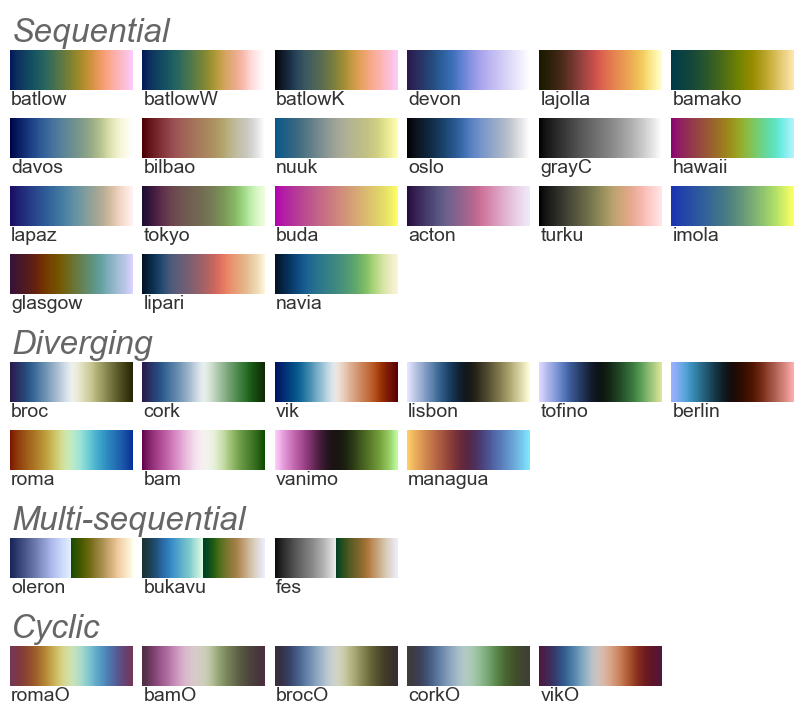

In [ ]:
cmcrameri.cm.show_cmaps()

In [ ]:
claas_frac_per_type

Cirrus             0.055531
Cirrostratus       0.047085
Deep convection    0.033098
Altocumulus        0.164555
Altostratus        0.155849
Nimbostratus       0.085113
Cumulus            0.196457
Stratocumulus      0.208601
Stratus            0.053067
Name: (2022-07-25 11:52:30, 0, 0.0, 0.0, 0.0), dtype: object

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 2 with shape (4,) and arg 3 with shape (9,).

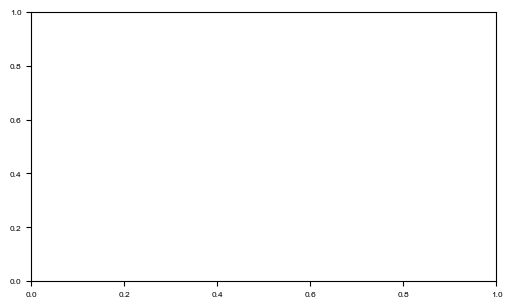

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# assume you have two pandas Series (or columns of a DataFrame) indexed by “Cloud type”:
full_frac  = claast_frac_per_type_series["Fraction tracked"]
reg_frac   = fraction_of_reg_per_type["Fraction tracked"]
#   types      = list of cloud‐type names, in the order you want them plotted

# for demo purposes let me make some dummy data:
types = frac_tracked["Cloud type"].unique()
# full_frac = np.array([85, 60, 25, 30])    # your claast_frac_per_type values
reg_frac  = np.array([75, 55,  3,  2])    # your fraction_of_reg_per_type values

# positions along the y‐axis
y_pos = np.arange(len(types))

fig, ax = plt.subplots(figsize=(6, 3.5))

# draw the “full” bars
ax.barh(y_pos, full_frac,
        height=0.8,
        color="#2166ac",    # dark blue
        edgecolor="k",
        label="Total cloud‐area fraction")

# draw the “inner” bars on top, with a smaller height
ax.barh(y_pos, reg_frac,
        height=0.8,
        color="#67a9cf",    # lighter blue
        edgecolor="k",
        label="Reg.‐area fraction")

# label the y‐axis with the full cloud‐type names
ax.set_yticks(y_pos)
ax.set_yticklabels(types, fontsize=10)
ax.invert_yaxis()  # highest bar on top

# axes labels & legend
ax.set_xlabel("Fraction tracked [%]")
ax.set_title("Fraction of cloud area tracked per cloud type")
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()


In [ ]:
# fraction_of_reg_per_type = fraction_of_reg_per_type.reset_index(name="Fraction tracked")

,Cloud type,Fraction tracked
7,Stratocumulus,0.208601
6,Cumulus,0.196457
3,Altocumulus,0.164555
4,Altostratus,0.155849
5,Nimbostratus,0.085113
0,Cirrus,0.055531
8,Stratus,0.053067
1,Cirrostratus,0.047085
2,Deep convection,0.033098


In [ ]:
(frac_tracked["Fraction tracked"]/100*claas_frac_per_type_df["Fraction tracked"]/100).sum()

0.30906044590273046

In [ ]:
# frac_tracked["Fraction tracked"] = frac_tracked["Fraction tracked"]/10000

Cloud type
Altocumulus        0.006762
Altostratus        0.076012
Cirrostratus       0.004732
Cirrus             0.000301
Cumulus            0.013055
Deep convection    0.005773
Nimbostratus       0.045802
Stratocumulus      0.133466
Stratus            0.015207
Name: normalized_area, dtype: float64

In [ ]:
frac_tracked

,Cloud type,Fraction tracked
0,Altocumulus,4.109108
1,Altostratus,48.772511
2,Cirrostratus,10.050847
3,Cirrus,0.542423
4,Cumulus,6.645428
5,Deep convection,17.442509
6,Nimbostratus,53.81256
7,Stratocumulus,63.981431
8,Stratus,28.656872


In [ ]:
frac_of_type_tracked

,Cloud type,Fraction tracked
0,Altocumulus,0.002282
1,Altostratus,0.022965
2,Cirrostratus,0.003327
3,Cirrus,0.000893
4,Cumulus,0.010357
5,Deep convection,0.014846
6,Nimbostratus,0.105719
7,Stratocumulus,0.133466
8,Stratus,0.015207


In [ ]:
frac_tracked

,Cloud type,Fraction tracked
0,Altocumulus,4.109108
1,Altostratus,48.772511
2,Cirrostratus,10.050847
3,Cirrus,0.542423
4,Cumulus,6.645428
5,Deep convection,17.442509
6,Nimbostratus,53.81256
7,Stratocumulus,63.981431
8,Stratus,28.656872


In [ ]:
frac_tracked

,Cloud type,Fraction tracked
0,Altocumulus,4.109108
1,Altostratus,48.772511
2,Cirrostratus,10.050847
3,Cirrus,0.542423
4,Cumulus,6.645428
5,Deep convection,17.442509
6,Nimbostratus,53.81256
7,Stratocumulus,63.981431
8,Stratus,28.656872


In [ ]:
frac_tracked.set_index("Cloud type")["Fraction tracked"]/100 * claas_frac_per_type_df.set_index("Cloud type")["Fraction tracked"]/100 *100

Cloud type
Altocumulus         0.676174
Altostratus         7.601171
Cirrostratus        0.473247
Cirrus              0.030121
Cumulus             1.305542
Deep convection     0.577315
Nimbostratus        4.580153
Stratocumulus      13.346602
Stratus             1.520731
Name: Fraction tracked, dtype: object

In [ ]:
frac_of_type_tracked

,Cloud type,Fraction tracked
0,Stratocumulus,NaN
1,Cumulus,NaN
2,Altocumulus,NaN
3,Altostratus,NaN
4,Nimbostratus,NaN
5,Cirrus,NaN
6,Stratus,NaN
7,Cirrostratus,NaN
8,Deep convection,NaN


In [ ]:
frac_sorted

,Cloud type,Fraction tracked
0,Stratocumulus,63.981431
1,Cumulus,6.645428
2,Altocumulus,4.109108
3,Altostratus,48.772511
4,Nimbostratus,53.81256
5,Cirrus,0.542423
6,Stratus,28.656872
7,Cirrostratus,10.050847
8,Deep convection,17.442509


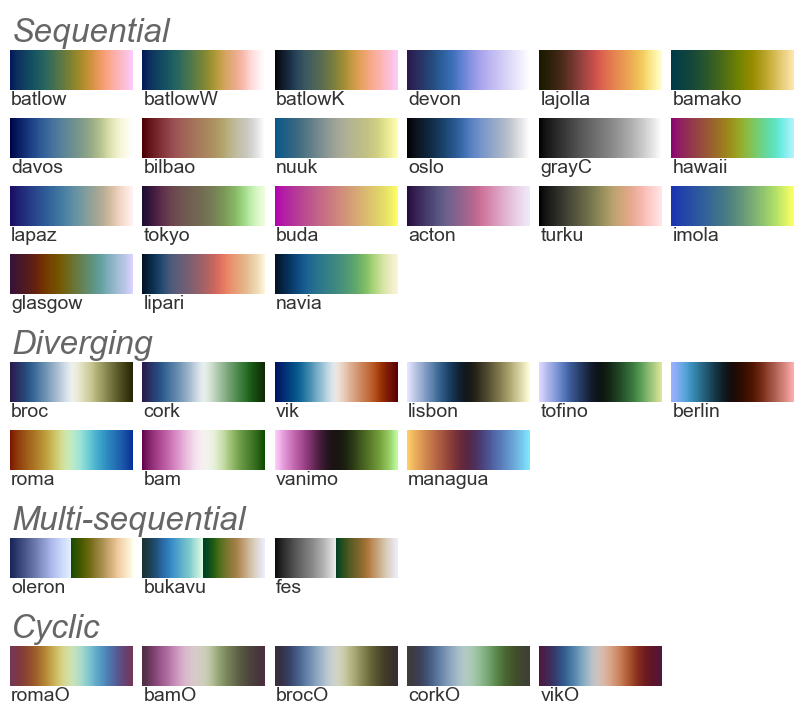

In [ ]:
cmcrameri.cm.show_cmaps()

/tmp/ipykernel_8248/3168983671.py:51: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  for patch in leg.legendHandles:


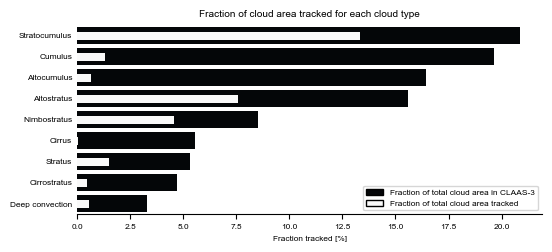

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
claas_frac_per_type_df = claas_frac_per_type_series.iloc[1:].reset_index(name="Fraction tracked").rename(columns={"index": "Cloud type"}).sort_values(by="Fraction tracked",ascending=False)
claas_frac_per_type_df
# Prepare data
claas_frac_per_type_df.loc[:, "Fraction tracked"] *= 100
# frac_tracked#.loc[:, "Fraction tracked"] *= 100  # Assuming these were also in fraction format (0-1)

# Sort both dataframes by the same order for consistency (optional but recommended)
order = claas_frac_per_type_df.sort_values("Fraction tracked", ascending=False)["Cloud type"]
claas_sorted = claas_frac_per_type_df.set_index("Cloud type").loc[order].reset_index()
frac_sorted = frac_tracked.set_index("Cloud type").loc[order].reset_index()
frac_of_type_tracked = frac_sorted.copy()
frac_of_type_tracked["Fraction tracked"] = frac_sorted["Fraction tracked"]/100 * claas_sorted["Fraction tracked"]/100 *100




# Plot
fig, ax = plt.subplots(figsize=(5.5, 2.5))
sns.barplot(
    data=claas_sorted,
    y="Cloud type",
    x="Fraction tracked",
    ax=ax,
    palette=cmcrameri.cm.osloS.colors[0:1],
    label="Fraction of total cloud area in CLAAS-3"
)

# Overlay bars with smaller width
sns.barplot(
    data=frac_of_type_tracked,
    y="Cloud type",
    x="Fraction tracked",
    ax=ax,
    color=cmcrameri.cm.osloS.colors[1:2],  # Or another visible color
    # alpha=0.6,
    width=0.4,  # Thinner bars
    label="Fraction of total cloud area tracked"
)

# Labels and formatting
ax.set_xlabel("Fraction tracked [%]")
ax.set_ylabel("")
# Hide only the tick *marks* (not the labels)
ax.tick_params(axis='y', which='both', length=0)
ax.set_title("Fraction of cloud area tracked for each cloud type")
leg = ax.legend(loc="lower right")
for patch in leg.legendHandles:
    patch.set_edgecolor("black")
    patch.set_linewidth(1.0)
# Remove top and right spines, and left spine line (but keep labels)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)  # Removes only the line, not the ticks or label
fig.tight_layout()

# Save the figure
# fig.savefig(os.path.join(GTE_DIR, "Result_graphs/Publication_figures", "Tracked_fractions_horizontal.pdf"))


In [ ]:
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(5.501,3.5 ), constrained_layout=True)
gs = gridspec.GridSpec(1, 2,width_ratios=[3,1],figure=fig)#,hspace=1.2, wspace=0.3)#,# Remove all borders and ticks.
ax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[0, 0],projection=ccrs.Robinson(central_longitude=0))


claas_frac_per_type_df = claas_frac_per_type_series.iloc[1:].reset_index(name="Fraction tracked").rename(columns={"index": "Cloud type"}).sort_values(by="Fraction tracked",ascending=False)
claas_frac_per_type_df
# Prepare data
claas_frac_per_type_df.loc[:, "Fraction tracked"] *= 100
# frac_tracked#.loc[:, "Fraction tracked"] *= 100  # Assuming these were also in fraction format (0-1)

# Sort both dataframes by the same order for consistency (optional but recommended)
order = claas_frac_per_type_df.sort_values("Fraction tracked", ascending=False)["Cloud type"]
claas_sorted = claas_frac_per_type_df.set_index("Cloud type").loc[order].reset_index()
frac_sorted = frac_tracked.set_index("Cloud type").loc[order].reset_index()
frac_of_type_tracked = frac_sorted.copy()
frac_of_type_tracked["Fraction tracked"] = frac_sorted["Fraction tracked"]/100 * claas_sorted["Fraction tracked"]/100 *100




# Plot
# fig, ax1 = plt.subplots(figsize=(5.5, 2.5))
sns.barplot(
    data=claas_sorted,
    y="Cloud type",
    x="Fraction tracked",
    ax=ax1,
    palette=cmcrameri.cm.osloS.colors[0:1],
    label="Fraction of total cloud area in CLAAS-3"
)

# Overlay bars with smaller width
sns.barplot(
    data=frac_of_type_tracked,
    y="Cloud type",
    x="Fraction tracked",
    ax=ax1,
    color=cmcrameri.cm.osloS.colors[1:2],  # Or another visible color
    # alpha=0.6,
    width=0.4,  # Thinner bars
    label="Fraction of total cloud area tracked"
)

# Labels and formatting
ax1.set_xlabel("Fraction tracked [%]")
ax1.set_ylabel("")
# Hide only the tick *marks* (not the labels)
ax1.tick_params(axis='y', which='both', length=0)
ax1.set_xticks(np.linspace(0, 22.5, 10))  # Set x-ticks from 0 to 100 with step of 20
ax1.set_yticklabels(claas_sorted["Cloud type"],rotation=45)  # Set x-ticks from 0 to 100 with step of 20
ax1.set_xticks(np.arange(0, 45, 1)/2,minor=True)  # Set x-ticks from 0 to 100 with step of 20
ax1.set_xlim(0, 22.5)  # Set x-axis limits from 0 to 100
# ax1.set_title("Fraction of cloud area tracked for each cloud type")
leg = ax1.legend(loc="lower right")
for patch in leg.legendHandles:
    patch.set_edgecolor("black")
    patch.set_linewidth(1.0)
# Remove top and right spines, and left spine line (but keep labels)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_visible(False)  # Removes only the line, not the ticks or label


######
# MAP
########


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ---- Example DataFrame 'sample' ----
# sample = pd.DataFrame({'avg_lon': [...], 'avg_lat': [...]})
sample=combined_cloud_df
# 1. Define bin edges for 1° increments
lon_bins = np.arange(-80, 82, 1)
lat_bins = np.arange(-80, 82, 1)

# 2. Compute the 2D histogram
heatmap, lon_edges, lat_edges = np.histogram2d(
    sample['avg_lon'],
    sample['avg_lat'],
    bins=[lon_bins, lat_bins]
)

# 3. Mask zero-count cells so they're transparent
area_factors = np.tile(abs(np.cos(lat_bins[:-1]/180*np.pi)).T,(161,1))* 111*111
heatmap /=area_factors
heatmap *=1000
masked_heatmap = np.ma.masked_where(heatmap == 0, heatmap)

# 4. Set up the figure and Cartopy axes — use Robinson now
# fig = plt.figure(figsize=(3.504, 3.504))
# ax2 = plt.axes(projection=ccrs.Robinson(central_longitude=0))

# Often for Robinson, setting a global extent is a nice choice:
# ax2.set_global()
ax2.set_extent([-80, 80, -90, 90], crs=ccrs.PlateCarree())
# 5. Add a simple land background (light gray), behind everything
ax2.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)

# 6. Add lat/lon gridlines *behind* the heatmap
# Note: For certain projections like Robinson, labeling can sometimes be problematic.
gl = ax2.gridlines(draw_labels=True, zorder=1, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False
# area_factors = np.tile(abs(np.cos(lat_bins[:-1]/180*np.pi)).T,(161,1))* 111*111
# 7. Plot the heatmap on top (higher z-order than grid)
mesh = ax2.pcolormesh(
    lon_edges,
    lat_edges,
    masked_heatmap.T,    # transpose to align axes
    transform=ccrs.PlateCarree(),
    shading='nearest',
    cmap='cmc.acton',
    # cmap='difference_plot_cmap',
    zorder=2
)

# 8. Add coastlines *above* the heatmap
ax2.add_feature(cfeature.COASTLINE, linewidth=1, zorder=3)

# (No country borders added, per your requirement)

# 9. Add colorbar
cbar = plt.colorbar(mesh, ax=ax2, location='bottom',shrink=0.95)
cbar.set_label('Number of Cloud Fragments per 1000 km²',fontsize=6)

fig.savefig(
    os.path.join(GTE_DIR,"Result_graphs","Publication_figures/Database_figure.pdf"),
    format="pdf",
    dpi=300
    # no bbox_inches argument at all
)
# ax2.set_title('1° x 1° Area Normalized Heatmap of \nClouds Fragment Number in 2022', fontsize=6,fontweight='bold' )
# plt.savefig(os.path.join(GTE_DIR,"Result_graphs/Cloud_number_map_combined.png"),dpi=400,bbox_inches='tight')
# plt.savefig(
#     "/wolke_scratch/dnikolo/Glaciation_time_estimator/Result_graphs/Publication_figures/Detection_map.pdf",
#     format="pdf",
#     dpi=300
#     # no bbox_inches argument at all
# )
# plt.show()



NameError: name 'plt' is not defined

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ---- Example DataFrame 'sample' ----
# sample = pd.DataFrame({'avg_lon': [...], 'avg_lat': [...]})
sample=combined_cloud_df
# 1. Define bin edges for 1° increments
lon_bins = np.arange(-80, 82, 1)
lat_bins = np.arange(-80, 82, 1)

# 2. Compute the 2D histogram
heatmap, lon_edges, lat_edges = np.histogram2d(
    sample['avg_lon'],
    sample['avg_lat'],
    bins=[lon_bins, lat_bins]
)

# 3. Mask zero-count cells so they're transparent
area_factors = np.tile(abs(np.cos(lat_bins[:-1]/180*np.pi)).T,(161,1))* 111*111
heatmap /=area_factors
heatmap *=1000
masked_heatmap = np.ma.masked_where(heatmap == 0, heatmap)

# 4. Set up the figure and Cartopy axes — use Robinson now
# fig = plt.figure(figsize=(3.504, 3.504))
# ax2 = plt.axes(projection=ccrs.Robinson(central_longitude=0))

# Often for Robinson, setting a global extent is a nice choice:
# ax2.set_global()
ax2.set_extent([-80, 80, -90, 90], crs=ccrs.PlateCarree())
# 5. Add a simple land background (light gray), behind everything
ax2.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)

# 6. Add lat/lon gridlines *behind* the heatmap
# Note: For certain projections like Robinson, labeling can sometimes be problematic.
gl = ax2.gridlines(draw_labels=True, zorder=1, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False
# area_factors = np.tile(abs(np.cos(lat_bins[:-1]/180*np.pi)).T,(161,1))* 111*111
# 7. Plot the heatmap on top (higher z-order than grid)
mesh = ax2.pcolormesh(
    lon_edges,
    lat_edges,
    masked_heatmap.T,    # transpose to align axes
    transform=ccrs.PlateCarree(),
    shading='nearest',
    cmap='cmc.acton',
    # cmap='difference_plot_cmap',
    zorder=2
)

# 8. Add coastlines *above* the heatmap
ax2.add_feature(cfeature.COASTLINE, linewidth=1, zorder=3)

# (No country borders added, per your requirement)

# 9. Add colorbar
cbar = plt.colorbar(mesh, ax2=ax2, orientation='vertical',shrink=0.95)
cbar.set_label('Number of Cloud Fragments per 1000 km²',fontsize=6)

# ax2.set_title('1° x 1° Area Normalized Heatmap of \nClouds Fragment Number in 2022', fontsize=6,fontweight='bold' )
# plt.savefig(os.path.join(GTE_DIR,"Result_graphs/Cloud_number_map_combined.png"),dpi=400,bbox_inches='tight')
plt.savefig(
    "/wolke_scratch/dnikolo/Glaciation_time_estimator/Result_graphs/Publication_figures/Detection_map.pdf",
    format="pdf",
    dpi=300
    # no bbox_inches argument at all
)
plt.show()


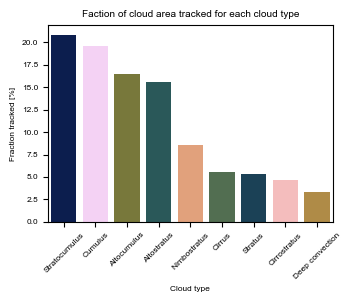

In [ ]:
fig, ax = plt.subplots(figsize=(3.5,3))
# claas_frac_per_type_df_sorted = claas_frac_per_type_df.iloc[1:].sort_values(by="Fraction tracked",ascending=False)
claas_frac_per_type_df.loc[:, "Fraction tracked"] *= 100  # Convert to percentage
bar = sns.barplot(data = claas_frac_per_type_df,x="Cloud type",y="Fraction tracked",ax=ax,palette=cmcrameri.cm.batlowS.colors)
ax.set_ylabel("Fraction tracked [%]")
ax.set_title("Faction of cloud area tracked for each cloud type")
# ax.set_xlabel(frac_tracked["Cloud type"],rotation=45)
bar.set_xticklabels(claas_frac_per_type_df["Cloud type"],rotation=45)
fig.tight_layout()
fig.savefig(os.path.join(GTE_DIR,"Result_graphs/Publication_figures","Tracked_fractions.pdf"))